In [29]:
from sklearn.datasets import make_regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [8]:
x,y = make_regression(n_samples = 100, n_features = 2, n_informative = 2, n_targets = 1, noise = 50)

In [10]:
df = pd.DataFrame({"feature_1": x[:,0], "feature_2": x[:,1], "target": y})
df

,feature_1,feature_2,target
0,-1.210451,2.370845,-28.443973
1,-0.427196,0.830699,-91.038286
2,-0.363448,0.789399,-45.605940
3,1.870825,-0.441962,27.551651
4,0.520851,2.041419,52.183517
...,...,...,...
95,0.642485,-1.212491,59.709899
96,-1.468189,1.059488,-52.409157
97,0.999035,0.450458,6.603031
98,-0.317999,-1.523834,-42.014692


In [12]:
df.shape

(100, 3)

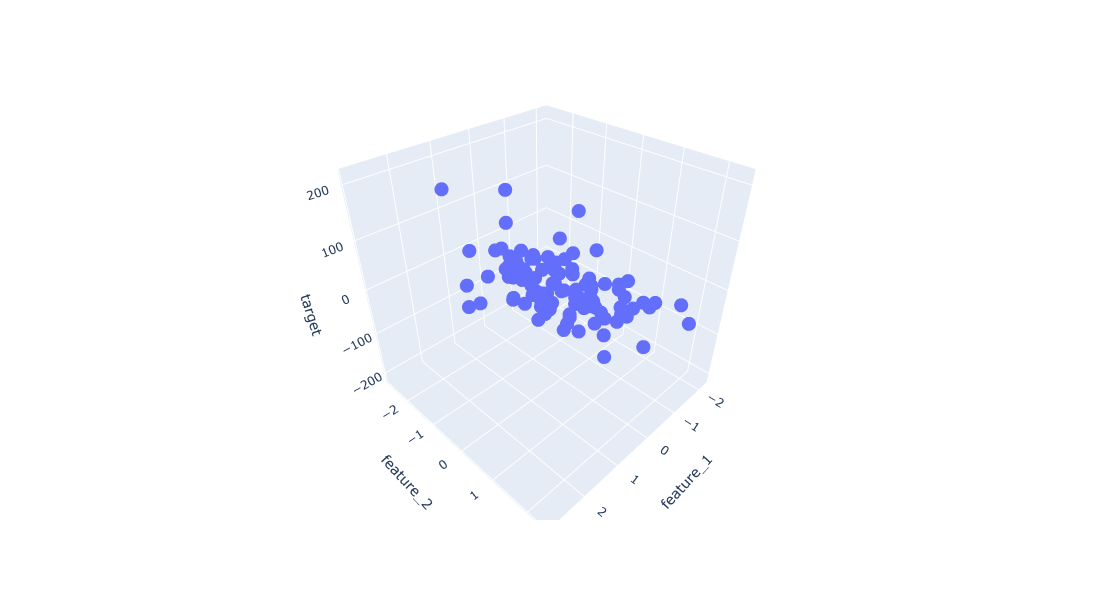

In [26]:
fig = px.scatter_3d(df, x= "feature_1", y = "feature_2", z = "target")
fig.update_layout(height = 600)
fig.show()

# Sameenu nay kia smjha isay

### Points phelay hua hain feature_1 or feature_2 ka koi strong relation nhi hain target say, bhut scatter points hain

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [32]:
len(X_train)

80

In [33]:
len(X_test)

20

# Feature Scaling

In [35]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [36]:
X_train

array([[-1.08823276, -2.94966138],
       [ 0.74794924, -0.70591436],
       [ 0.06314449, -0.08884039],
       [-0.13632753, -0.15708484],
       [-0.57367234, -0.48705189],
       [ 1.92307318,  0.54916669],
       [ 0.92050995,  0.99862509],
       [-1.75655744,  1.06927633],
       [-2.52089144,  0.77995897],
       [-0.53345526,  1.62959952],
       [-1.41954029,  1.60188923],
       [ 1.95562607, -0.75182678],
       [-0.04544556, -1.36842873],
       [-0.66787525, -1.23307329],
       [-0.06138398, -1.91437923],
       [-0.30679877, -0.48640708],
       [ 1.19728569, -1.6126271 ],
       [ 1.14867231,  0.45328221],
       [ 1.05960852, -0.48457349],
       [ 1.01346864,  1.55648427],
       [ 0.79682749,  1.03456996],
       [ 0.50015512, -0.31337846],
       [-0.36643382, -1.58912806],
       [ 0.50057993, -1.35716081],
       [ 0.13524752, -0.46249806],
       [-0.90450808, -0.26648424],
       [-0.53716111,  0.381787  ],
       [-0.13061926, -0.73512515],
       [ 0.1266435 ,

In [37]:
X_test

array([[-1.39680208e+00, -2.28356593e+00],
       [-1.74628955e+00, -1.22090926e+00],
       [ 1.74665830e+00, -2.77911400e-02],
       [-1.64818454e+00,  5.07706019e-01],
       [-1.78527972e+00, -1.39094111e-01],
       [ 1.98414533e-01, -4.98078106e-01],
       [-1.16575923e+00,  2.87157313e-01],
       [-3.43241927e-01,  1.34521789e+00],
       [-2.53434038e-01, -6.59973568e-01],
       [-1.48093441e+00,  2.46978418e+00],
       [-1.12883458e+00, -3.26652555e-02],
       [ 1.08545891e+00,  1.91622066e+00],
       [ 1.95264390e+00, -1.26065319e+00],
       [-9.57786811e-01,  5.71739823e-01],
       [ 1.46229675e+00,  2.18917064e-01],
       [ 3.70505747e-01,  2.11796298e+00],
       [ 8.84059441e-01,  1.24466769e+00],
       [ 8.87335538e-01, -5.62383570e-01],
       [ 8.53059836e-01,  6.40498952e-04],
       [-4.73300739e-01, -5.74287013e-02]])

# Create Linear Regression Model

In [38]:
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Predictions

In [39]:
y_pred = regressor.predict(X_test)
y_pred

array([-71.79810922, -82.1971805 ,  92.87836313, -67.07208426,
       -77.55663914,  15.62904716, -45.21215055,   0.69422089,
        -7.06425332, -47.21758597, -45.36329743,  72.8041381 ,
        95.35496299, -33.50209092,  80.6960148 ,  39.65436105,
        59.07969793,  48.35520922,  50.09822463, -14.00378988])

In [40]:
compare = pd.DataFrame({"Actual": Y_test,
                        "Predicted":y_pred})

In [41]:
compare

,Actual,Predicted
0,-59.449529,-71.798109
1,-59.882208,-82.197180
2,142.313509,92.878363
3,-82.380856,-67.072084
4,-57.227022,-77.556639
5,-75.699131,15.629047
6,-83.961392,-45.212151
7,53.596939,0.694221
8,-40.173571,-7.064253
9,-28.443973,-47.217586


# Now using regression metrics

In [45]:
print("Mean Absolute Error (MAE): ", mean_absolute_error(Y_test,y_pred))
print("Mean Square Error (MSE): ", mean_squared_error(Y_test,y_pred))
print("Root Mean Square Error (RMSE): ", np.sqrt(mean_squared_error(Y_test,y_pred)))
print('R2-score: ', r2_score(Y_test,y_pred))

Mean Absolute Error (MAE):  35.71358482362062
Mean Square Error (MSE):  2008.9903039800488
Root Mean Square Error (RMSE):  44.8217615001915
R2-score:  0.7132967664233691
